# Pre-Fit and Post-Fit plots
This notebook plots the pre/post-fit plots using the outputs from running runcards.py and runcombine.py. Firstly, make a `fitDiagnosticsTest.root` by running the `fitdiagnostics.sh` script for a particular signal point.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import hist.intervals
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import chi2
import mplhep as hep
import os
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerLine2D
import plot_utils

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.max_open_warning': 0})
matplotlib.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 70
plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [32]:
AN_label = "/home/submit/"+os.environ['USER']+"/SUEP/AN-23-183/images/{}.pdf"
save_to_AN = True

In [4]:
filename = "../cards/WH_1_25/cards-SUEP_mS125.000_mPhi4.000_T4.000_modegeneric/fitDiagnosticsTest.root"  # replace with your actual ROOT file path
file = uproot.open(filename)

In [5]:
def compute_poisson_interval(values, confidence=0.6827):
    alpha = 1 - confidence
    low = chi2.ppf(alpha / 2., 2 * values) / 2
    high = chi2.ppf(1. - alpha / 2., 2 * (values + 1)) / 2
    #low[np.isnan(low)] = 0
    return low, high

lumis = {
    "2016_apv": 19497.914,
    "2016": 16810.813,
    "2017": 41471.589,
    "2018": 59817.406,
    "all": 19497.914 + 16810.813 + 41471.589 + 59817.406,
}

def lumiLabel(year):
    if year in ["2017", "2018"]:
        return round(lumis[year] / 1000, 1)
    elif year == "2016":
        return round((lumis[year] + lumis[year + "_apv"]) / 1000, 1)
    elif year == 'all':
        return round(lumis[year] / 1000, 1)

In [30]:
def read_post_fit_file(postFitFile, bins, years, regions):
   
    payload, payload_err = {}, {}
    for region in regions:
        
        payload[region], payload_err[region] = {}, {}

        for year in years:

            payload[region][year], payload_err[region][year] = {}, {}

            for fit in ['fit_s', 'fit_b', 'prefit']:
                   
                payload[region][year][fit], payload_err[region][year][fit] = {}, {}
                payload[region][year]['data'], payload_err[region][year]['data'] = {}, {}

                for bin in bins:

                    name = 'shapes_{}/{}{};1'.format(fit, region+bin, year)
                    
                    payload[region][year][fit][bin] = postFitFile[name][region+'expected;1'].values()[0]
                    payload_err[region][year][fit][bin] = np.sqrt(postFitFile[name]['total_covar;1'].to_numpy()[0][0][0])

                    payload[region][year]['data'][bin] = postFitFile[name]['data;1'].values()[1][0]
                    payload_err[region][year]['data'][bin] = np.array(compute_poisson_interval(payload[region][year]['data'][bin]))

    return payload, payload_err

def create_plot_objects(_rpayload, _rpayload_err, lepton=''):

    hist_defs = {
        'A': {'channels': ['crA'], 'bins': [10, 20]},
        'B': {'channels': ['crB'], 'bins': [20, 30]},
        'C': {'channels': ['crC'], 'bins': [30, 120]},
        'D': {'channels': ['crD'], 'bins': [10, 20]},
        'E': {'channels': ['crE'], 'bins': [20, 30]},
        'F': {'channels': ['crF0', 'crF1', 'crF2', 'crF3', 'crF4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'G': {'channels': ['crG'], 'bins': [10, 20]},
        'H': {'channels': ['crH'], 'bins': [20, 30]},
        'SR': {'channels': ['sr0', 'sr1', 'sr2', 'sr3', 'sr4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }

    # temporary
    hist_defs = {
        'A': {'channels': ['crA'], 'bins': [10, 20]},
        'B': {'channels': ['crB'], 'bins': [20, 30]},
        'C': {'channels': ['crC'], 'bins': [30, 120]},
        'D': {'channels': ['crD'], 'bins': [10, 20]},
        'E': {'channels': ['crE'], 'bins': [20, 30]},
        'F': {'channels': ['crF0', 'crF1', 'crF2', 'crF3', 'crF4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'G': {'channels': ['crG'], 'bins': [10, 20]},
        'H': {'channels': ['crH'], 'bins': [20, 30]},
        'SR': {'channels': ['sr0', 'sr1', 'sr2', 'sr3', 'sr4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }
    for region in hist_defs.keys():
        hist_defs[region]['channels'] = [lepton+channel for channel in hist_defs[region]['channels']]


    for hist_name, hist_def in hist_defs.items():

        # pre fit values (only relevant for ABCD prediction in SR, other regions are identical to data observed)
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['all']['prefit'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['prefit'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['prefit'] = h

        # post fit values for each region
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['all']['fit_b'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['fit_b'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_b'] = h

        # post fit values for each region, s+b
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['all']['fit_s'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['fit_s'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_s'] = h

        print("fit_b: ", hist_defs[hist_name]['fit_b'].values())
        print("fit_s", hist_defs[hist_name]['fit_s'].values())

        # observed data for each region
        hist_defs[hist_name]['centers'] = h.axes[0].centers
        values = np.array([_rpayload['all']['data'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['data'][ch] for ch in hist_def['channels']])
        errors[np.isnan(errors)] = 0
        hist_defs[hist_name]['data'] = values
        hist_defs[hist_name]['data_err'] = np.array([values-errors[:,0], errors[:,1] - values])

        # get values of ratio of post-fit to observed data
        r_post_data = np.divide(hist_defs[hist_name]['fit_b'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_post_data_err = np.sqrt( ((hist_defs[hist_name]['fit_b'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['fit_b'].variances()))
        hist_defs[hist_name]['r_post_data'] = r_post_data
        hist_defs[hist_name]['r_post_data_err'] = r_post_data_err

        # get values of ratio of post-fit to observed data, s+b
        r_post_data = np.divide(hist_defs[hist_name]['fit_s'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_post_data_err = np.sqrt( ((hist_defs[hist_name]['fit_s'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['fit_s'].variances()))
        hist_defs[hist_name]['r_post_data_s'] = r_post_data
        hist_defs[hist_name]['r_post_data_err_s'] = r_post_data_err

        # get values of ratio of pre-fit to observed data 
        r_prefit_data = np.divide(hist_defs[hist_name]['prefit'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_prefit_data_err = np.sqrt( ((hist_defs[hist_name]['prefit'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['prefit'].values()))
        hist_defs[hist_name]['r_prefit_data'] = r_prefit_data
        hist_defs[hist_name]['r_prefit_data_err'] = r_prefit_data_err
    
    return hist_defs

def getSignalHists(signal, year):

    if year == 'all':
        hists = {}
        for y in ['2016', '2017', '2018']:
            _hists = getSignalHistsYear(signal, y)
            for k, v in _hists.items():
                if k in hists:
                    hists[k] += v
                else:
                    hists[k] = v
        return hists
    
    else:
        return getSignalHistsYear(signal, year)

def getSignalHistsYear(signal, year):

    import yaml
    import json

    with open(f'../config/WH_inputs_{year}.yaml') as f:
        config = yaml.safe_load(f)

    files = config[signal]['files']

    with open(f"../config/xsections_{year}.json") as f:
        xsections = json.load(f)

    norm = xsections[signal]["xsec"] * xsections[signal]["kr"] * xsections[signal]["br"] * lumis[year]

    hists = {}
    for f in files:
        _f = uproot.open(f)
        for k in _f.keys():
            if 'SUEP_nconst' not in k: continue
            if 'cutflow' in k: continue
            try:
                if k in hists:
                    hists[k.split(';')[0]] += _f[k].to_hist() * norm
                else:
                    hists[k.split(';')[0]] = _f[k].to_hist() * norm
            except:
                print(k, "failed.")
    
    return hists

def make_postfit(plot_objs, region='', signals=[], fit_x='fit_b', both=False):

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(27, 9), sharey=False, sharex=True, 
                            gridspec_kw={'height_ratios': [3,1], 'hspace':0.1, 'wspace':0}) #Plot 3 subplots
    fig.subplots_adjust(wspace=0) 
    (ax1, ax2, ax3) = axes[0]
    (ax1r, ax2r, ax3r) = axes[1]

    ax1.errorbar(plot_objs['A']['centers'], plot_objs['A']['data'], plot_objs['A']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax1.errorbar(plot_objs['B']['centers'], plot_objs['B']['data'], plot_objs['B']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax1.errorbar(plot_objs['C']['centers'], plot_objs['C']['data'], plot_objs['C']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['D']['centers'], plot_objs['D']['data'], plot_objs['D']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['E']['centers'], plot_objs['E']['data'], plot_objs['E']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['F']['centers'], plot_objs['F']['data'], plot_objs['F']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['G']['centers'], plot_objs['G']['data'], plot_objs['G']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['H']['centers'], plot_objs['H']['data'], plot_objs['H']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['data'], plot_objs['SR']['data_err'], capsize=3, linestyle='', fmt='o', color='black')

    hep.histplot(plot_objs['SR']['prefit'], ax=ax3, color='slategray', yerr=False, linewidth=3)

    for hist_name, hist_def in plot_objs.items():
        if hist_name != 'SR': continue
        _bins = hist_def['bins']
        _vals = hist_def['prefit'].values()
        _vars = np.sqrt(hist_def['prefit'].variances())
        ax = ax1 if hist_name in ['A', 'B', 'C'] else ax2 if hist_name in ['D', 'E', 'F'] else ax3
        for i in range(len(_bins)-1):
            ax.fill_between([_bins[i], _bins[i+1]], 
                            _vals[i] - _vars[i], 
                            _vals[i] + _vars[i], 
                            color='slategray', alpha=0.3)

    hep.histplot(plot_objs['A'][fit_x], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['B'][fit_x], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['C'][fit_x], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['D'][fit_x], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['E'][fit_x], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['F'][fit_x], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['G'][fit_x], ax=ax3, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['H'][fit_x], ax=ax3, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['SR'][fit_x], ax=ax3, color='purple', yerr=False, linewidth=3)

    if both:
        fit_xx = 'fit_s' if fit_x == 'fit_b' else 'fit_b'
        hep.histplot(plot_objs['A'][fit_xx], ax=ax1, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['B'][fit_xx], ax=ax1, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['C'][fit_xx], ax=ax1, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['D'][fit_xx], ax=ax2, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['E'][fit_xx], ax=ax2, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['F'][fit_xx], ax=ax2, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['G'][fit_xx], ax=ax3, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['H'][fit_xx], ax=ax3, color='green', yerr=False, linewidth=3)
        hep.histplot(plot_objs['SR'][fit_xx], ax=ax3, color='green', yerr=False, linewidth=3)

    if signals:

        import sys
        sys.path.append('../')
        from ftool import rebin_piecewise

        colors = ['red', 'blue', 'green', 'orange', 'cyan', 'magenta', 'yellow', 'black', 'gray']
        for color, signal in zip(colors, signals):
            mPhi, T, mode = signal
            signal_hists = getSignalHists('SUEP_mS125.000_mPhi{:.3f}_T{:.3f}_mode{}'.format(mPhi, T, mode), 'all')
            _label = "$m_{\phi} = " + str(mPhi) + " $ GeV\n$T_D = " + str(T) + "$ GeV\n$m_{A'} = " + str(plot_utils.mA[mode]) + "$ GeV"
            hep.histplot(rebin_piecewise(signal_hists[f'A_SUEP_nconst_SR'], plot_objs['A'][fit_x].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'B_SUEP_nconst_SR'], plot_objs['B'][fit_x].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'C_SUEP_nconst_SR'], plot_objs['C'][fit_x].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'D_SUEP_nconst_SR'], plot_objs['D'][fit_x].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'E_SUEP_nconst_SR'], plot_objs['E'][fit_x].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'F_SUEP_nconst_SR'], plot_objs['F'][fit_x].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3, label=_label)
            hep.histplot(rebin_piecewise(signal_hists[f'G_SUEP_nconst_SR'], plot_objs['G'][fit_x].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'H_SUEP_nconst_SR'], plot_objs['H'][fit_x].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'I_SUEP_nconst_SR'], plot_objs['SR'][fit_x].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)

    _bins = hist_def['bins']
    _vals = hist_def[fit_x].values()
    _vars = np.sqrt(hist_def[fit_x].variances())
    ax = ax1 if hist_name in ['A', 'B', 'C'] else ax2 if hist_name in ['D', 'E', 'F'] else ax3
    for i in range(len(_bins)-1):
        ax.fill_between([_bins[i], _bins[i+1]], 
                        _vals[i] - _vars[i], 
                        _vals[i] + _vars[i], 
                        color='purple', alpha=0.3)

    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_prefit_data'], plot_objs['SR']['r_prefit_data_err'], capsize=3, linestyle='', fmt='o', color='slategray')

    ax1r.errorbar(plot_objs['A']['centers'], plot_objs['A']['r_post_data_s'], plot_objs['A']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax1r.errorbar(plot_objs['B']['centers'], plot_objs['B']['r_post_data_s'], plot_objs['B']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax1r.errorbar(plot_objs['C']['centers'], plot_objs['C']['r_post_data_s'], plot_objs['C']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax2r.errorbar(plot_objs['D']['centers'], plot_objs['D']['r_post_data_s'], plot_objs['D']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax2r.errorbar(plot_objs['E']['centers'], plot_objs['E']['r_post_data_s'], plot_objs['E']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax2r.errorbar(plot_objs['F']['centers'], plot_objs['F']['r_post_data_s'], plot_objs['F']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax3r.errorbar(plot_objs['G']['centers'], plot_objs['G']['r_post_data_s'], plot_objs['G']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax3r.errorbar(plot_objs['H']['centers'], plot_objs['H']['r_post_data_s'], plot_objs['H']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')
    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_post_data_s'], plot_objs['SR']['r_post_data_err_s'], capsize=3, linestyle='', fmt='o', color='green')

    ax1r.errorbar(plot_objs['A']['centers'], plot_objs['A']['r_post_data'], plot_objs['A']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax1r.errorbar(plot_objs['B']['centers'], plot_objs['B']['r_post_data'], plot_objs['B']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax1r.errorbar(plot_objs['C']['centers'], plot_objs['C']['r_post_data'], plot_objs['C']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['D']['centers'], plot_objs['D']['r_post_data'], plot_objs['D']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['E']['centers'], plot_objs['E']['r_post_data'], plot_objs['E']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['F']['centers'], plot_objs['F']['r_post_data'], plot_objs['F']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['G']['centers'], plot_objs['G']['r_post_data'], plot_objs['G']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['H']['centers'], plot_objs['H']['r_post_data'], plot_objs['H']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_post_data'], plot_objs['SR']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')

    # pretty up
    line, = plt.plot(range(10), color = 'purple')
    patch = mpatches.Patch(facecolor='purple', alpha=0.3, linewidth=0)
    line_s, = plt.plot(range(10), color = 'green')
    patch_s = mpatches.Patch(facecolor='green', alpha=0.3, linewidth=0)
    line2, = plt.plot(range(10), color = 'slategray')
    patch2 = mpatches.Patch(facecolor='slategray', alpha=0.3, linewidth=0)
    line3 = plt.errorbar(1000,0, yerr=10, label='Observed', linestyle='',c='black',capsize=2.0,fmt ='.')
    map = {'fit_b': 'b-only', 'fit_s': 's+b'}
    string = map[fit_x]
    ax3.legend([line3, (patch, line), (patch_s, line_s), (patch2, line2)], 
            ["Observed", "Post-Fit\n(b-only)", "Post-Fit\n("+string+")", "Pre-Fit"], 
            handler_map = {line : HandlerLine2D(marker_pad = 0)}, 
            loc=(0.65, 0.25), fontsize=18)       
    if signals: ax2.legend(loc=(0.65, 0.2), fontsize=14)
    cms = ax1.text(
        0.0,1.01, u"CMS",
        fontsize=24, fontweight='bold',
        transform=ax1.transAxes, 
        horizontalalignment='left'
    )
    lumi = ax3.text(
        1.0,1.01, r"%.0f fb$^{-1}$ ($13$ TeV)" % round(lumiLabel('all')),
        transform=ax3.transAxes, 
        horizontalalignment='right'
    )
    ax1.set_ylabel('Events')
    if region in ['GJHS', 'WJHS']:
        ax1.text(0.95, 0.95, '0.3 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.4', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.4 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.5', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.5 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 1.0', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    elif region in ['GJLS', 'WJLS']:
        ax1.text(0.95, 0.95, '0.05 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.15', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.15 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.25', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.25 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.3', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    ax1.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax2.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax3.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax1.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax2.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax3.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax1r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax2r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax3r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax1r.set_ylim(0.8, 1.2)
    ax2r.set_ylim(0.8, 1.2)
    ax3r.set_ylim(0.8, 1.2)
    ax1.set_xlim(10, 125)
    ax2.set_xlim(10, 125)
    ax3.set_xlim(10, 125)
    ax1.set_ylim(5e-1, 3e6)
    ax2.set_ylim(5e-1, 3e6)
    ax3.set_ylim(5e-1, 3e6)
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax3.set_xlabel('')
    ax1r.set_ylabel("Pred./Obs.")
    ax3r.set_xlabel('$n^{\mathrm{SUEP}}_{\mathrm{constituents}}$')
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax3.set_yscale("log")
    for i in range(2):
        for j in range(3):
            if j > 0:  # Check if the column is not the first column
                axes[i, j].set_yticklabels([])  # Remove y-axis labels
    fig.tight_layout()
    fig.show()

    return fig, (ax1, ax2, ax3), (ax1r, ax2r, ax3r)

In [20]:
def read_post_fit_file(postFitFile, bins, years, regions):
   
    payload, payload_err = {}, {}
    for region in regions:
        
        payload[region], payload_err[region] = {}, {}

        for year in years:

            payload[region][year], payload_err[region][year] = {}, {}
        
            for fit in ['fit_b', 'prefit']:
                   
                payload[region][year][fit], payload_err[region][year][fit] = {}, {}
                payload[region][year]['data'], payload_err[region][year]['data'] = {}, {}

                for bin in bins:

                    name = 'shapes_{}/{}{};1'.format(fit, region+bin, year)
                    
                    payload[region][year][fit][bin] = postFitFile[name][region+'expected;1'].values()[0]
                    payload_err[region][year][fit][bin] = np.sqrt(postFitFile[name]['total_covar;1'].to_numpy()[0][0][0])

                    payload[region][year]['data'][bin] = postFitFile[name]['data;1'].values()[1][0]
                    payload_err[region][year]['data'][bin] = np.array(compute_poisson_interval(payload[region][year]['data'][bin]))

    return payload, payload_err

def create_plot_objects(_rpayload, _rpayload_err, lepton=''):

    hist_defs = {
        'A': {'channels': ['crA'], 'bins': [10, 20]},
        'B': {'channels': ['crB'], 'bins': [20, 30]},
        'C': {'channels': ['crC'], 'bins': [30, 120]},
        'D': {'channels': ['crD'], 'bins': [10, 20]},
        'E': {'channels': ['crE'], 'bins': [20, 30]},
        'F': {'channels': ['crF0', 'crF1', 'crF2', 'crF3', 'crF4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'G': {'channels': ['crG'], 'bins': [10, 20]},
        'H': {'channels': ['crH'], 'bins': [20, 30]},
        'SR': {'channels': ['sr0', 'sr1', 'sr2', 'sr3', 'sr4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }

    # temporary
    hist_defs = {
        'A': {'channels': ['crA'], 'bins': [10, 20]},
        'B': {'channels': ['crB'], 'bins': [20, 30]},
        'C': {'channels': ['crC'], 'bins': [30, 120]},
        'D': {'channels': ['crD'], 'bins': [10, 20]},
        'E': {'channels': ['crE'], 'bins': [20, 30]},
        'F': {'channels': ['crF0', 'crF1', 'crF2', 'crF3', 'crF4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'G': {'channels': ['crG'], 'bins': [10, 20]},
        'H': {'channels': ['crH'], 'bins': [20, 30]},
        'SR': {'channels': ['sr0', 'sr1', 'sr2', 'sr3', 'sr4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }
    for region in hist_defs.keys():
        hist_defs[region]['channels'] = [lepton+channel for channel in hist_defs[region]['channels']]


    for hist_name, hist_def in hist_defs.items():

        # pre fit values (only relevant for ABCD prediction in SR, other regions are identical to data observed)
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['all']['prefit'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['prefit'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['prefit'] = h

        # post fit values for each region
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['all']['fit_b'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['fit_b'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_b'] = h

        # observed data for each region
        hist_defs[hist_name]['centers'] = h.axes[0].centers
        values = np.array([_rpayload['all']['data'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['all']['data'][ch] for ch in hist_def['channels']])
        errors[np.isnan(errors)] = 0
        hist_defs[hist_name]['data'] = values
        hist_defs[hist_name]['data_err'] = np.array([values-errors[:,0], errors[:,1] - values])

        # get values of ratio of post-fit to observed data
        r_post_data = np.divide(hist_defs[hist_name]['fit_b'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_post_data_err = np.sqrt( ((hist_defs[hist_name]['fit_b'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['fit_b'].variances()))
        hist_defs[hist_name]['r_post_data'] = r_post_data
        hist_defs[hist_name]['r_post_data_err'] = r_post_data_err

        # get values of ratio of pre-fit to observed data 
        r_prefit_data = np.divide(hist_defs[hist_name]['prefit'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_prefit_data_err = np.sqrt( ((hist_defs[hist_name]['prefit'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['prefit'].values()))
        hist_defs[hist_name]['r_prefit_data'] = r_prefit_data
        hist_defs[hist_name]['r_prefit_data_err'] = r_prefit_data_err
    
    return hist_defs

def getSignalHists(signal, year):

    if year == 'all':
        hists = {}
        for y in ['2016', '2017', '2018']:
            _hists = getSignalHistsYear(signal, y)
            for k, v in _hists.items():
                if k in hists:
                    hists[k] += v
                else:
                    hists[k] = v
        return hists
    
    else:
        return getSignalHistsYear(signal, year)

def getSignalHistsYear(signal, year):

    import yaml
    import json

    with open(f'../config/WH_inputs_{year}.yaml') as f:
        config = yaml.safe_load(f)

    files = config[signal]['files']

    with open(f"../config/xsections_{year}.json") as f:
        xsections = json.load(f)

    norm = xsections[signal]["xsec"] * xsections[signal]["kr"] * xsections[signal]["br"] * lumis[year]

    hists = {}
    for f in files:
        _f = uproot.open(f)
        for k in _f.keys():
            if 'SUEP_nconst' not in k: continue
            if 'cutflow' in k: continue
            try:
                if k in hists:
                    hists[k.split(';')[0]] += _f[k].to_hist() * norm
                else:
                    hists[k.split(';')[0]] = _f[k].to_hist() * norm
            except:
                print(k, "failed.")
    
    return hists

def make_postfit(plot_objs, region='', signals=[]):

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(27, 9), sharey=False, sharex=True, 
                            gridspec_kw={'height_ratios': [3,1], 'hspace':0.1, 'wspace':0}) #Plot 3 subplots
    fig.subplots_adjust(wspace=0) 
    (ax1, ax2, ax3) = axes[0]
    (ax1r, ax2r, ax3r) = axes[1]

    ax1.errorbar(plot_objs['A']['centers'], plot_objs['A']['data'], plot_objs['A']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax1.errorbar(plot_objs['B']['centers'], plot_objs['B']['data'], plot_objs['B']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax1.errorbar(plot_objs['C']['centers'], plot_objs['C']['data'], plot_objs['C']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['D']['centers'], plot_objs['D']['data'], plot_objs['D']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['E']['centers'], plot_objs['E']['data'], plot_objs['E']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['F']['centers'], plot_objs['F']['data'], plot_objs['F']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['G']['centers'], plot_objs['G']['data'], plot_objs['G']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['H']['centers'], plot_objs['H']['data'], plot_objs['H']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['data'], plot_objs['SR']['data_err'], capsize=3, linestyle='', fmt='o', color='black')

    hep.histplot(plot_objs['SR']['prefit'], ax=ax3, color='slategray', yerr=False, linewidth=3)

    for hist_name, hist_def in plot_objs.items():
        if hist_name != 'SR': continue
        _bins = hist_def['bins']
        _vals = hist_def['prefit'].values()
        _vars = np.sqrt(hist_def['prefit'].variances())
        ax = ax1 if hist_name in ['A', 'B', 'C'] else ax2 if hist_name in ['D', 'E', 'F'] else ax3
        for i in range(len(_bins)-1):
            ax.fill_between([_bins[i], _bins[i+1]], 
                            _vals[i] - _vars[i], 
                            _vals[i] + _vars[i], 
                            color='slategray', alpha=0.3)

    hep.histplot(plot_objs['A']['fit_b'], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['B']['fit_b'], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['C']['fit_b'], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['D']['fit_b'], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['E']['fit_b'], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['F']['fit_b'], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['G']['fit_b'], ax=ax3, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['H']['fit_b'], ax=ax3, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['SR']['fit_b'], ax=ax3, color='purple', yerr=False, linewidth=3)

    if signals:

        import sys
        sys.path.append('../')
        from ftool import rebin_piecewise

        colors = ['red', 'blue', 'green', 'orange', 'cyan', 'magenta', 'yellow', 'black', 'gray']
        for color, signal in zip(colors, signals):
            mPhi, T, mode = signal
            signal_hists = getSignalHists('SUEP_mS125.000_mPhi{:.3f}_T{:.3f}_mode{}'.format(mPhi, T, mode), 'all')
            _label = "$m_{\phi} = " + str(mPhi) + " $ GeV\n$T_D = " + str(T) + "$ GeV\n$m_{A'} = " + str(plot_utils.mA[mode]) + "$ GeV"
            hep.histplot(rebin_piecewise(signal_hists[f'A_SUEP_nconst_SR'], plot_objs['A']['fit_b'].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'B_SUEP_nconst_SR'], plot_objs['B']['fit_b'].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'C_SUEP_nconst_SR'], plot_objs['C']['fit_b'].axes[0].edges), ax=ax1, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'D_SUEP_nconst_SR'], plot_objs['D']['fit_b'].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'E_SUEP_nconst_SR'], plot_objs['E']['fit_b'].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'F_SUEP_nconst_SR'], plot_objs['F']['fit_b'].axes[0].edges), ax=ax2, color=color, yerr=True, linewidth=3, label=_label)
            hep.histplot(rebin_piecewise(signal_hists[f'G_SUEP_nconst_SR'], plot_objs['G']['fit_b'].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'H_SUEP_nconst_SR'], plot_objs['H']['fit_b'].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)
            hep.histplot(rebin_piecewise(signal_hists[f'I_SUEP_nconst_SR'], plot_objs['SR']['fit_b'].axes[0].edges), ax=ax3, color=color, yerr=True, linewidth=3)

    _bins = hist_def['bins']
    _vals = hist_def['fit_b'].values()
    _vars = np.sqrt(hist_def['fit_b'].variances())
    ax = ax1 if hist_name in ['A', 'B', 'C'] else ax2 if hist_name in ['D', 'E', 'F'] else ax3
    for i in range(len(_bins)-1):
        ax.fill_between([_bins[i], _bins[i+1]], 
                        _vals[i] - _vars[i], 
                        _vals[i] + _vars[i], 
                        color='purple', alpha=0.3)

    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_prefit_data'], plot_objs['SR']['r_prefit_data_err'], capsize=3, linestyle='', fmt='o', color='slategray')

    ax1r.errorbar(plot_objs['A']['centers'], plot_objs['A']['r_post_data'], plot_objs['A']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax1r.errorbar(plot_objs['B']['centers'], plot_objs['B']['r_post_data'], plot_objs['B']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax1r.errorbar(plot_objs['C']['centers'], plot_objs['C']['r_post_data'], plot_objs['C']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['D']['centers'], plot_objs['D']['r_post_data'], plot_objs['D']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['E']['centers'], plot_objs['E']['r_post_data'], plot_objs['E']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['F']['centers'], plot_objs['F']['r_post_data'], plot_objs['F']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['G']['centers'], plot_objs['G']['r_post_data'], plot_objs['G']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['H']['centers'], plot_objs['H']['r_post_data'], plot_objs['H']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_post_data'], plot_objs['SR']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')

    # pretty up
    line, = plt.plot(range(10), color = 'purple')
    patch = mpatches.Patch(facecolor='purple', alpha=0.3, linewidth=0)
    line2, = plt.plot(range(10), color = 'slategray')
    patch2 = mpatches.Patch(facecolor='slategray', alpha=0.3, linewidth=0)
    line3 = plt.errorbar(1000,0, yerr=10, label='Observed', linestyle='',c='black',capsize=2.0,fmt ='.')
    ax3.legend([line3, (patch, line), (patch2, line2)], 
            ["Observed", "Post-Fit\n(b. only)", "Pre-Fit"], 
            handler_map = {line : HandlerLine2D(marker_pad = 0)}, 
            loc=(0.65, 0.40), fontsize=18)       
    if signals: ax2.legend(loc=(0.65, 0.2), fontsize=14)
    cms = ax1.text(
        0.0,1.01, u"CMS",
        fontsize=24, fontweight='bold',
        transform=ax1.transAxes, 
        horizontalalignment='left'
    )
    lumi = ax3.text(
        1.0,1.01, r"%.0f fb$^{-1}$ ($13$ TeV)" % round(lumiLabel('all')),
        transform=ax3.transAxes, 
        horizontalalignment='right'
    )
    ax1.set_ylabel('Events')
    if region in ['GJHS', 'WJHS']:
        ax1.text(0.95, 0.95, '0.3 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.4', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.4 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.5', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.5 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 1.0', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    elif region in ['GJLS', 'WJLS']:
        ax1.text(0.95, 0.95, '0.05 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.15', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.15 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.25', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.25 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.3', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    ax1.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax2.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax3.axvline(20, color='gray', linewidth=3, linestyle='-')
    ax1.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax2.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax3.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax1r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax2r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax3r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax1r.set_ylim(0.1, 1.8)
    ax2r.set_ylim(0.1, 1.8)
    ax3r.set_ylim(0.1, 1.8)
    ax1.set_xlim(10, 125)
    ax2.set_xlim(10, 125)
    ax3.set_xlim(10, 125)
    ax1.set_ylim(5e-1, 3e6)
    ax2.set_ylim(5e-1, 3e6)
    ax3.set_ylim(5e-1, 3e6)
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax3.set_xlabel('')
    ax1r.set_ylabel("Pred./Obs.")
    ax3r.set_xlabel('$n^{\mathrm{SUEP}}_{\mathrm{constituents}}$')
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax3.set_yscale("log")
    for i in range(2):
        for j in range(3):
            if j > 0:  # Check if the column is not the first column
                axes[i, j].set_yticklabels([])  # Remove y-axis labels
    fig.tight_layout()
    fig.show()

    return fig, (ax1, ax2, ax3), (ax1r, ax2r, ax3r)

In [14]:
years = ['all']
bins = [
    'sr0','sr1','sr2','sr3','sr4',
    'crF0','crF1','crF2','crF3','crF4',
    'crA', 'crB', 'crC', 'crD', 'crE', 'crG', 'crH',
]
regions = ['WJHS']

payload, payload_err = read_post_fit_file(file, bins, years, regions)
payload

{'WJHS': {'all': {'fit_s': {'sr0': 56226.38,
    'sr1': 4033.8564,
    'sr2': 340.05762,
    'sr3': 29.473885,
    'sr4': 4.6691278e-09,
    'crF0': 23518.584,
    'crF1': 1694.6113,
    'crF2': 141.90189,
    'crF3': 12.522698,
    'crF4': 1.9527402e-09,
    'crA': 1436676.8,
    'crB': 279821.53,
    'crC': 22031.822,
    'crD': 1012128.5,
    'crE': 290360.16,
    'crG': 1168943.8,
    'crH': 559243.9},
   'data': {'sr0': 56220.0,
    'sr1': 4032.0,
    'sr2': 341.0,
    'sr3': 29.0,
    'sr4': 0.0,
    'crF0': 23532.0,
    'crF1': 1697.0,
    'crF2': 141.0,
    'crF3': 13.0,
    'crF4': 0.0,
    'crA': 1436669.0,
    'crB': 279837.0,
    'crC': 22024.0,
    'crD': 1012144.0,
    'crE': 290329.0,
    'crG': 1168936.0,
    'crH': 559259.0},
   'fit_b': {'sr0': 56226.668,
    'sr1': 4033.839,
    'sr2': 340.08914,
    'sr3': 29.482082,
    'sr4': 6.9313626e-09,
    'crF0': 23518.324,
    'crF1': 1694.6577,
    'crF2': 141.90608,
    'crF3': 12.522397,
    'crF4': 2.8988127e-09,
    'c

In [15]:
payload_err

{'WJHS': {'all': {'fit_s': {'sr0': 224.47896,
    'sr1': 56.32398,
    'sr2': 16.30533,
    'sr3': 4.4469376,
    'sr4': 8.748583e-05,
    'crF0': 187.16515,
    'crF1': 39.715275,
    'crF2': 7.93622,
    'crF3': 2.42155,
    'crF4': 2.6193973e-05,
    'crA': 1285.8463,
    'crB': 528.89355,
    'crC': 137.9144,
    'crD': 1017.0417,
    'crE': 563.3524,
    'crG': 1064.6115,
    'crH': 760.787},
   'data': {'sr0': array([55982.88799862, 56458.11413939]),
    'sr1': array([3968.5032309 , 4096.50467599]),
    'sr2': array([322.54247626, 360.48466659]),
    'sr3': array([23.6459664 , 35.44715258]),
    'sr4': array([       nan, 1.84105476]),
    'crF0': array([23378.59633627, 23686.40695279]),
    'crF1': array([1655.80851047, 1739.20366437]),
    'crF2': array([129.1395058 , 153.90271165]),
    'crF3': array([ 9.44127447, 17.6976684 ]),
    'crF4': array([       nan, 1.84105476]),
    'crA': array([1435470.36284793, 1437868.63759819]),
    'crB': array([279307.99262403, 280367.00835018

fit_b:  [1436676.625]
fit_s [1436676.75]
fit_b:  [279822.21875]
fit_s [279821.53125]
fit_b:  [22032.40429688]
fit_s [22031.82226562]
fit_b:  [1012128.875]
fit_s [1012128.5]
fit_b:  [290357.21875]
fit_s [290360.15625]
fit_b:  [2.35183242e+04 1.69465771e+03 1.41906082e+02 1.25223970e+01
 2.89881275e-09]
fit_s [2.35185840e+04 1.69461133e+03 1.41901886e+02 1.25226984e+01
 1.95274019e-09]
fit_b:  [1168943.625]
fit_s [1168943.75]
fit_b:  [559242.75]
fit_s [559243.875]
fit_b:  [5.62266680e+04 4.03383911e+03 3.40089142e+02 2.94820824e+01
 6.93136259e-09]
fit_s [5.62263789e+04 4.03385645e+03 3.40057617e+02 2.94738846e+01
 4.66912775e-09]


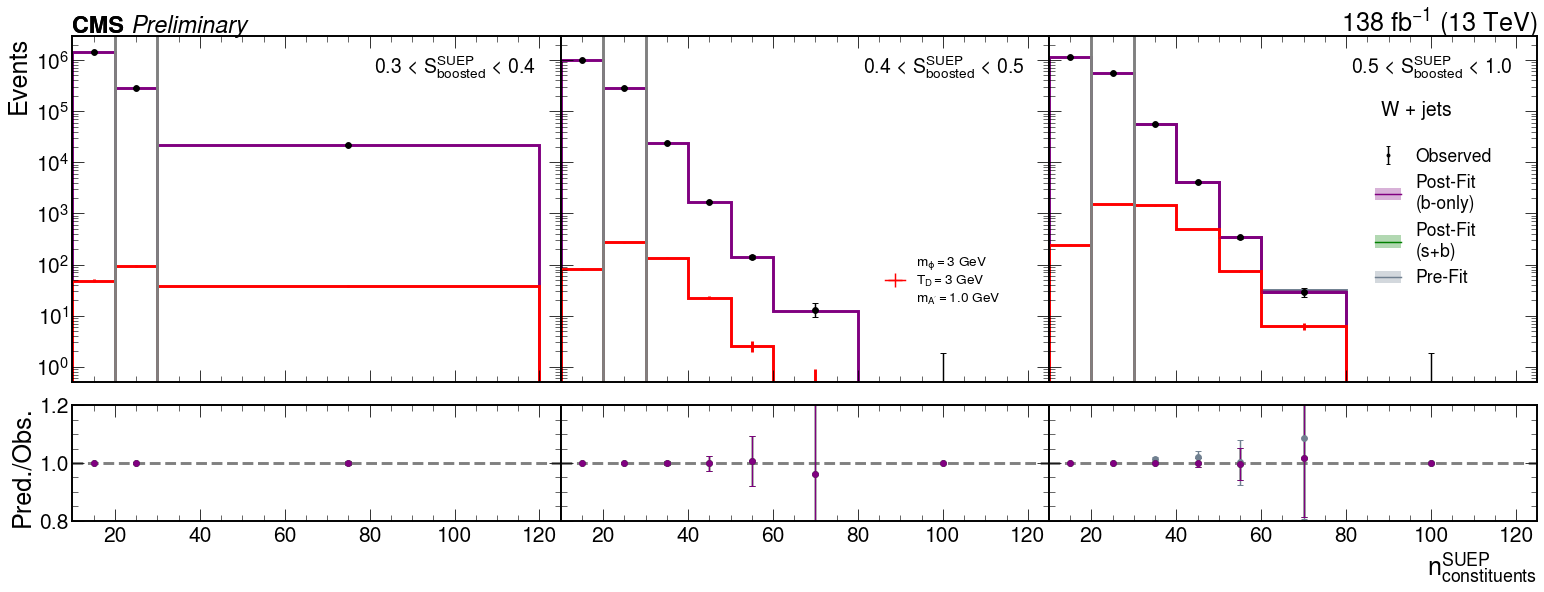

In [33]:
WJHS_plot_objs = create_plot_objects(payload['WJHS'], payload_err['WJHS'])
WJHSfig, WJHSaxs, WJHSaxrs = make_postfit(WJHS_plot_objs, region='WJHS', signals=[(3, 3, 'generic')], fit_x='fit_s')
WJHSaxs[2].text(0.68, 0.77, 'W + jets',
            fontsize=20, transform=WJHSaxs[2].transAxes)
cms = WJHSaxs[0].text(
    0.0, 1.01, u"CMS ",
    fontsize=24, fontweight='bold',
    transform=WJHSaxs[0].transAxes, 
    horizontalalignment='left'
)
simulation = WJHSaxs[0].text(
    0.12, 1.01, u"Preliminary",
    fontsize=24, fontstyle='italic',
    transform=WJHSaxs[0].transAxes, 
    horizontalalignment='left'
)
if save_to_AN: WJHSfig.savefig(AN_label.format('prepostfit'))

# WJHS_plot_objs = create_plot_objects(payload['WJHS'], payload_err['WJHS'], lepton='e')
# WJHSfig, WJHSaxs, WJHSaxrs = make_postfit(WJHS_plot_objs, region='WJHS', signals=[(3, 3, 'generic')])
# WJHSaxs[2].text(0.68, 0.77, 'W + jets',
#             fontsize=20, transform=WJHSaxs[2].transAxes)
# cms = WJHSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=WJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# simulation = WJHSaxs[0].text(
#     0.12, 1.01, u"Preliminary",
#     fontsize=24, fontstyle='italic',
#     transform=WJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# if save_to_AN: WJHSfig.savefig(AN_label.format('prepostfit'))

# WJLS_plot_objs = create_plot_objects(payload['WJLS'], payload_err['WJLS'])
# WJLSfig, WJLSaxs, WJLSaxrs = make_postfit(WJLS_plot_objs, region='WJLS')
# WJLSaxrs[2].text(0.68, 0.77, 'W + jets',
#             fontsize=20, transform=WJLSaxrs[2].transAxes)
# cms = WJLSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=WJLSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# GJLS_plot_objs = create_plot_objects(payload['GJLS'], payload_err['GJLS'])
# GJLSfig, GJLSaxs, GJLSaxrs = make_postfit(GJLS_plot_objs, region='GJLS')
# GJLSaxs[2].text(0.68, 0.77, '$\gamma$ + jets',
#             fontsize=20, transform=GJLSaxs[2].transAxes)
# cms = GJLSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=GJLSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# GJHS_plot_objs = create_plot_objects(payload['GJHS'], payload_err['GJHS'])
# GJHSfig, GJHSaxs, GJHSaxrs = make_postfit(
#     GJHS_plot_objs, region='GJHS',
#     signals=[(2, 2, 'generic'), (4, 4, 'generic'), (8, 8, 'generic')]
# )
# GJHSaxs[2].text(0.68, 0.77, '$\gamma$ + jets',
#             fontsize=20, transform=GJHSaxs[2].transAxes)
# cms = GJHSaxs[0].text(
#     0.0, 1.01, u"CMS ",
#     fontsize=24, fontweight='bold',
#     transform=GJHSaxs[0].transAxes, 
#     horizontalalignment='left'
# )
# _ = GJHSaxs[0].set_ylim(5e-1, 1e8)
# _ = GJHSaxs[1].set_ylim(5e-1, 1e8)
# _ = GJHSaxs[2].set_ylim(5e-1, 1e8)
# _ = GJHSaxrs[0].set_ylim(0.5, 1.3)
# _ = GJHSaxrs[1].set_ylim(0.5, 1.3)
# _ = GJHSaxrs[2].set_ylim(0.5, 1.3)

# if save_to_AN: GJHSfig.savefig(AN_label.format('VRGJ_prepostfit'))